In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# display settings
pd.set_option('display.max_columns', None)

In [92]:
df = pd.read_csv("SuperStore_Sales_Dataset.csv")

In [93]:
df.head()

,Row ID+O6G3A1:R6,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Profit,Returns,Payment Mode,ind1,ind2
0,4918,CA-2019-160304,01-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",73.94,1,28.2668,NaN,Online,NaN,NaN
1,4919,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,FUR-BO-10004709,Furniture,Bookcases,"Bush Westfield Collection Bookcases, Medium Ch...",173.94,3,38.2668,NaN,Online,NaN,NaN
2,4920,CA-2019-160304,02-01-2019,07-01-2019,Standard Class,BM-11575,Brendan Murry,Corporate,United States,Gaithersburg,Maryland,East,TEC-PH-10000455,Technology,Phones,GE 30522EE2,231.98,2,67.2742,NaN,Cards,NaN,NaN
3,3074,CA-2019-125206,03-01-2019,05-01-2019,First Class,LR-16915,Lena Radford,Consumer,United States,Los Angeles,California,West,OFF-ST-10003692,Office Supplies,Storage,Recycled Steel Personal File for Hanging File ...,114.46,2,28.6150,NaN,Online,NaN,NaN
4,8604,US-2019-116365,03-01-2019,08-01-2019,Standard Class,CA-12310,Christine Abelman,Corporate,United States,San Antonio,Texas,Central,TEC-AC-10002217,Technology,Accessories,Imation Clip USB flash drive - 8 GB,30.08,2,-5.2640,NaN,Online,NaN,NaN


In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5901 entries, 0 to 5900
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Row ID+O6G3A1:R6  5901 non-null   int64  
 1   Order ID          5901 non-null   object 
 2   Order Date        5901 non-null   object 
 3   Ship Date         5901 non-null   object 
 4   Ship Mode         5901 non-null   object 
 5   Customer ID       5901 non-null   object 
 6   Customer Name     5901 non-null   object 
 7   Segment           5901 non-null   object 
 8   Country           5901 non-null   object 
 9   City              5901 non-null   object 
 10  State             5901 non-null   object 
 11  Region            5901 non-null   object 
 12  Product ID        5901 non-null   object 
 13  Category          5901 non-null   object 
 14  Sub-Category      5901 non-null   object 
 15  Product Name      5901 non-null   object 
 16  Sales             5901 non-null   float64


In [95]:
df.describe()

,Row ID+O6G3A1:R6,Sales,Quantity,Profit,Returns,ind1,ind2
count,5901.000000,5901.000000,5901.000000,5901.000000,287.0,0.0,0.0
mean,5022.422471,265.345589,3.781901,29.700408,1.0,NaN,NaN
std,2877.977184,474.260645,2.212917,259.589138,0.0,NaN,NaN
min,1.000000,0.836000,1.000000,-6599.978000,1.0,NaN,NaN
25%,2486.000000,71.976000,2.000000,1.795500,1.0,NaN,NaN
50%,5091.000000,128.648000,3.000000,8.502500,1.0,NaN,NaN
75%,7456.000000,265.170000,5.000000,28.615000,1.0,NaN,NaN
max,9994.000000,9099.930000,14.000000,8399.976000,1.0,NaN,NaN


In [96]:
df.isnull().sum()

Row ID+O6G3A1:R6       0
Order ID               0
Order Date             0
Ship Date              0
Ship Mode              0
Customer ID            0
Customer Name          0
Segment                0
Country                0
City                   0
State                  0
Region                 0
Product ID             0
Category               0
Sub-Category           0
Product Name           0
Sales                  0
Quantity               0
Profit                 0
Returns             5614
Payment Mode           0
ind1                5901
ind2                5901
dtype: int64

In [97]:
df.duplicated().sum()

np.int64(0)

In [98]:
df = df.drop_duplicates()

In [99]:
df['Sales'] = df['Sales'].fillna(df['Sales'].mean())
df['Profit'] = df['Profit'].fillna(0)

In [100]:
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d-%m-%Y', errors='coerce')

In [101]:
df['Category'] = df['Category'].str.strip()
df['Region'] = df['Region'].str.strip()

In [102]:
top_states = df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(5)
print(top_states)

State
California      335190.2560
New York        186748.0970
Texas           116261.9302
Washington       92975.1800
Pennsylvania     82354.9500
Name: Sales, dtype: float64


In [103]:
category_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)
print(category_profit)

Category
Technology         90458.2486
Office Supplies    74797.2461
Furniture          10006.6112
Name: Profit, dtype: float64


In [104]:
region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
West       522441.0520
East       450234.6660
Central    341007.5242
South      252121.0810
Name: Sales, dtype: float64


In [105]:
df['Month'] = df['Order Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
2019-01     18616.4310
2019-02     19978.8150
2019-03     51715.8750
2019-04     38750.0390
2019-05     50987.7280
2019-06     40344.5340
2019-07     39261.9630
2019-08     31115.3743
2019-09     73410.0249
2019-10     42687.7450
2019-11     79411.9658
2019-12     78399.0430
2020-01     54763.3740
2020-02     52068.1334
2020-03     64229.3528
2020-04     50807.5361
2020-05     66750.1102
2020-06     69242.7257
2020-07     60077.4160
2020-08     77338.8880
2020-09    119803.6520
2020-10     88896.9232
2020-11    130960.8250
2020-12    166185.8488
Freq: M, Name: Sales, dtype: float64


In [106]:
sub_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values(ascending=False)
print(sub_profit.head())

Sub-Category
Copiers        42774.5828
Accessories    25336.6455
Phones         22308.9179
Paper          21112.3779
Binders        17885.3759
Name: Profit, dtype: float64


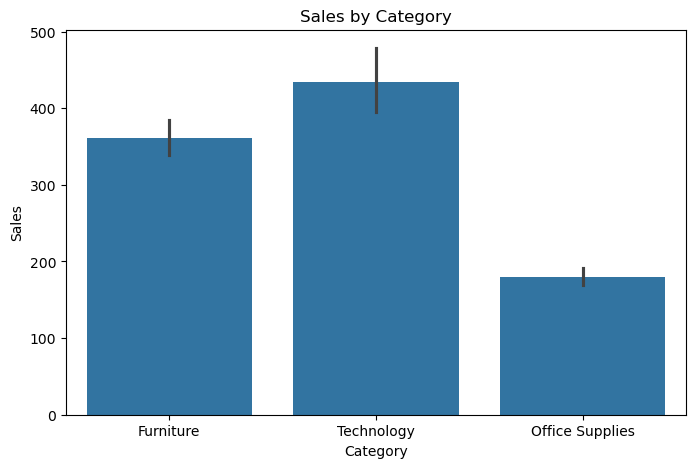

In [107]:
plt.figure(figsize=(8,5))
sns.barplot(x='Category', y='Sales', data=df)
plt.title("Sales by Category")
plt.show()

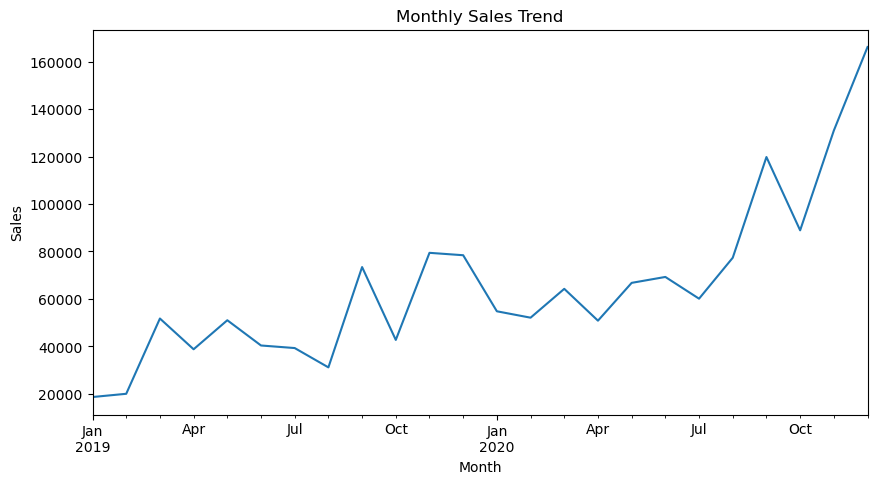

In [108]:
monthly_sales.plot(kind='line', figsize=(10,5))
plt.title("Monthly Sales Trend")
plt.ylabel("Sales")
plt.show()

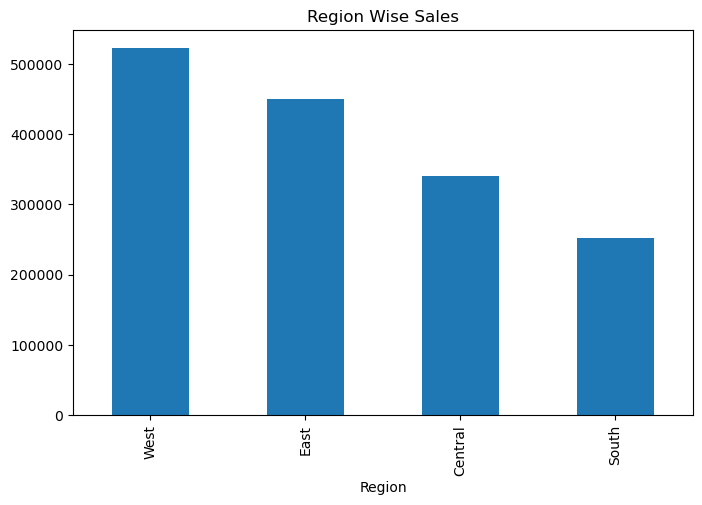

In [109]:
region_sales.plot(kind='bar', figsize=(8,5))
plt.title("Region Wise Sales")
plt.show()

# INSIGHTS
1.Technology category generates the highest sales revenue.

2.The Western region contributes the largest portion of total sales.

3.Phones and Chairs are among the most profitable sub-categories.

4.Sales show seasonal trends with certain months having higher sales.

5.Some sub-categories generate high sales but low profit, indicating high cost or discounting.

6.A few states dominate overall sales performance.